# M0 - Baseline regression lineaire (5 variables)

Objectif:
- entrainer une baseline lineaire sur `train.csv`
- utiliser uniquement les 5 variables retenues dans l'analyse
- comparer plusieurs strategies de preprocessing avec la meme CV
- selectionner la meilleure configuration puis generer une soumission Kaggle

Variables retenues:
`['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale', 'Neighborhood']`


In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

# Pour le VIF (installé si nécessaire)
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    VIF_AVAILABLE = True
except ImportError:
    print("statsmodels non disponible - analyse VIF skip")
    VIF_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [11]:
# Chargement des donnees
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "Data"

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")
print(f"sample_submission shape: {sample_submission.shape}")

# Feature engineering: AgeAtSale = annee de vente - annee de construction
for df in [train_df, test_df]:
    df["AgeAtSale"] = df["YrSold"] - df["YearBuilt"]

features = ["OverallQual", "GrLivArea", "TotalBsmtSF", "AgeAtSale", "Neighborhood"]
target = "SalePrice"

print("Features baseline:", features)


train shape: (1460, 81)
test shape: (1459, 80)
sample_submission shape: (1459, 2)
Features baseline: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale', 'Neighborhood']


## Détection des outliers

Analyse des outliers sur les variables de surface pour un baseline robuste.

Détection des outliers (méthode IQR):

GrLivArea:
  Nombre d'outliers: 31 (2.12%)
  Bornes: [158.62, 2747.62]

TotalBsmtSF:
  Nombre d'outliers: 61 (4.18%)
  Bornes: [42.00, 2052.00]


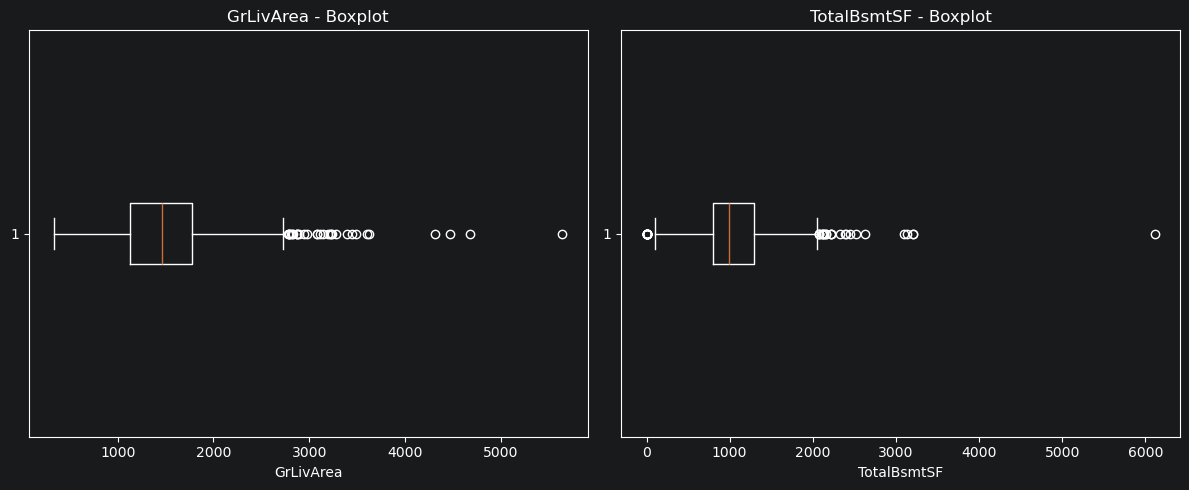


Variables winsorisées créées pour comparaison future.


In [12]:
# Détection des outliers sur les variables de surface
surface_vars = ['GrLivArea', 'TotalBsmtSF']

def detect_outliers_iqr(df, variables, threshold=1.5):
    """Détection des outliers avec la méthode IQR"""
    outliers_info = {}

    for var in variables:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

        outliers_info[var] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(df) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_indices': outliers.index.tolist(),
        }

    return outliers_info

# Détection des outliers
outliers_info = detect_outliers_iqr(train_df, surface_vars)

print("Détection des outliers (méthode IQR):")
for var, info in outliers_info.items():
    print(f"\n{var}:")
    print(f"  Nombre d'outliers: {info['count']} ({info['percentage']:.2f}%)")
    print(f"  Bornes: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")

# Visualisation des outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(surface_vars):
    axes[i].boxplot(train_df[var].dropna(), vert=False)
    axes[i].set_title(f'{var} - Boxplot')
    axes[i].set_xlabel(var)

plt.tight_layout()
plt.show()

# Option: Winsorisation (remplacer les outliers par les bornes)
def winsorize_series(series, lower_bound, upper_bound):
    return series.clip(lower_bound, upper_bound)

# Création de versions winsorisées pour comparaison éventuelle
train_df_winsorized = train_df.copy()
for var in surface_vars:
    info = outliers_info[var]
    train_df_winsorized[f'{var}_winsorized'] = winsorize_series(
        train_df[var], info['lower_bound'], info['upper_bound']
    )

print("\nVariables winsorisées créées pour comparaison future.")

--- Analyse IQR Initiale ---
GrLivArea: 31 outliers détectés (2.12%)
TotalBsmtSF: 61 outliers détectés (4.18%)


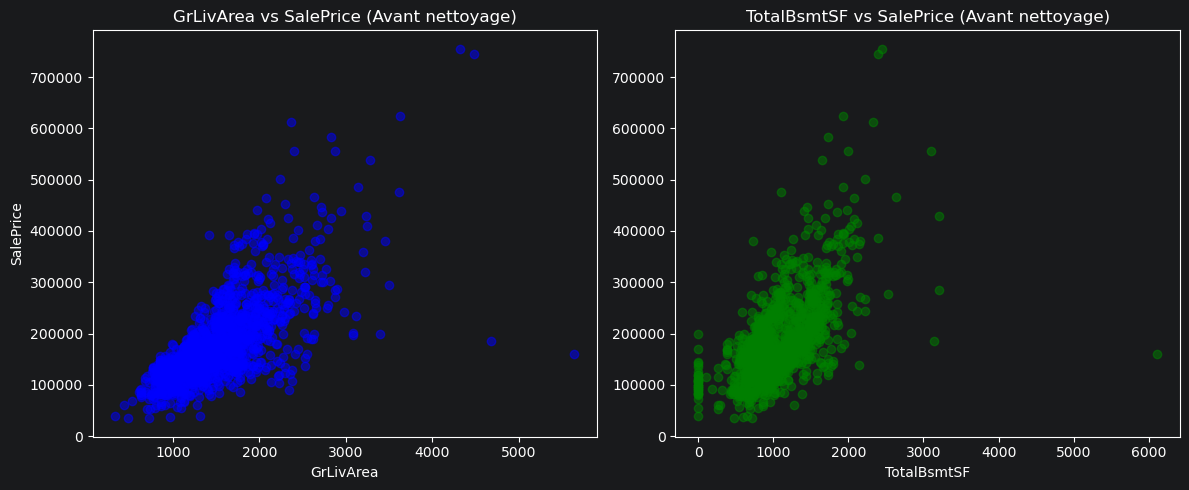


--- Nettoyage ---
Nombre d'outliers critiques supprimés (Surface énorme, prix bas) : 2
Nouveau shape du train set : (1458, 82)


In [13]:
## Détection et gestion des outliers
# 1. Analyse exploratoire avec la méthode IQR (Interquartile Range)
surface_vars = ['GrLivArea', 'TotalBsmtSF']


def detect_outliers_iqr(df, variables, threshold=1.5):
    """Détection des outliers avec la méthode IQR"""
    outliers_info = {}

    for var in variables:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

        outliers_info[var] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(df) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
        }

    return outliers_info


outliers_info = detect_outliers_iqr(train_df, surface_vars)

print("--- Analyse IQR Initiale ---")
for var, info in outliers_info.items():
    print(f"{var}: {info['count']} outliers détectés ({info['percentage']:.2f}%)")

# 2. Visualisation avant nettoyage (Scatter plot : Surface vs Prix)
# C'est LE graphique qui permet de comprendre pourquoi on supprime ces points
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=0.5, color='blue')
axes[0].set_title('GrLivArea vs SalePrice (Avant nettoyage)')
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')

axes[1].scatter(train_df['TotalBsmtSF'], train_df['SalePrice'], alpha=0.5, color='green')
axes[1].set_title('TotalBsmtSF vs SalePrice (Avant nettoyage)')
axes[1].set_xlabel('TotalBsmtSF')

plt.tight_layout()
plt.show()

# 3. SUPPRESSION CIBLÉE (Recommandation de la documentation)
# On supprime les maisons énormes (>4000 sqft) mais étonnamment peu chères.
# On évite de supprimer les maisons >4000 sqft qui SONT très chères (ce sont de vrais manoirs).

condition_aberrante = (train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)
outliers_a_supprimer = train_df[condition_aberrante]

print(f"\n--- Nettoyage ---")
print(f"Nombre d'outliers critiques supprimés (Surface énorme, prix bas) : {len(outliers_a_supprimer)}")

# On met à jour le dataframe d'entraînement
train_df = train_df.drop(outliers_a_supprimer.index).reset_index(drop=True)

print(f"Nouveau shape du train set : {train_df.shape}")

# Optionnel : Tu pourrais refaire un nuage de points ici pour montrer que les "points en bas à droite" ont disparu.

## Vérification des valeurs manquantes

Avant d'aller plus loin, vérifions les valeurs manquantes pour nos 5 variables de base.

In [14]:
# Verification des valeurs manquantes pour les 5 variables
missing_train = train_df[features].isna().mean().mul(100).sort_values(ascending=False)
missing_test = test_df[features].isna().mean().mul(100).sort_values(ascending=False)

print("Missing % (train):")
print(missing_train)
print("\nMissing % (test):")
print(missing_test)


Missing % (train):
OverallQual     0.0
GrLivArea       0.0
TotalBsmtSF     0.0
AgeAtSale       0.0
Neighborhood    0.0
dtype: float64

Missing % (test):
TotalBsmtSF     0.06854
OverallQual     0.00000
GrLivArea       0.00000
AgeAtSale       0.00000
Neighborhood    0.00000
dtype: float64


In [15]:
# X / y
X_train = train_df[features].copy()
X_test = test_df[features].copy()

y_train = train_df[target].copy()
y_train_log = np.log1p(y_train)


In [16]:
# 3. PREPROCESSING (Architecture claire inspirée du M3)

from sklearn.impute import KNNImputer

# Définition des métriques (comme tu l'avais fait)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Groupes de colonnes
num_features = ["OverallQual", "GrLivArea", "AgeAtSale"]
num_zero_features = ["TotalBsmtSF"] # NaN = Pas de sous-sol
cat_features = ["Neighborhood"]

# 1. Pipeline Numérique (KNNImputer comme dans M3 + StandardScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

# 2. Pipeline "Zéro" pour le sous-sol (Logique métier)
zero_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# 3. Pipeline Catégorielle (Mode + OneHotEncoder adapté à la Régression Linéaire)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# L'assembleur final (Le fameux ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('num_zero', zero_transformer, num_zero_features),
        ('cat', categorical_transformer, cat_features)
    ])

# Création du pipeline complet de la Baseline
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

print("Pipeline Baseline créé avec succès !")

Pipeline Baseline créé avec succès !


In [17]:
# 4. ÉVALUATION DE LA BASELINE (Validation Croisée 5-Fold)

from sklearn.model_selection import cross_validate

print("Début de l'évaluation du modèle Baseline (Linear Regression)...")

# On définit les métriques que l'on veut observer
scoring = {
    'rmse_log': make_scorer(rmse, greater_is_better=False),
    'r2': 'r2'
}

# Lancement de la validation croisée sur le Pipeline complet
# On utilise y_train_log car le modèle doit prédire le log du prix
cv_results = cross_validate(
    baseline_pipeline,
    X_train,
    y_train_log,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# Extraction et nettoyage des résultats
mean_rmse_cv = -cv_results['test_rmse_log'].mean()
std_rmse_cv = cv_results['test_rmse_log'].std()

mean_r2_cv = cv_results['test_r2'].mean()
std_r2_cv = cv_results['test_r2'].std()

print("\n--- RÉSULTATS DE LA VALIDATION CROISÉE (5-Fold) ---")
print(f"RMSE (Log Price)  : {mean_rmse_cv:.5f} (+/- {std_rmse_cv:.5f})")
print(f"R² Score          : {mean_r2_cv:.5f} (+/- {std_r2_cv:.5f})")

# Vérification de l'overfitting (Comparaison Train vs Test)
mean_rmse_train = -cv_results['train_rmse_log'].mean()
print(f"\nRMSE sur le Train : {mean_rmse_train:.5f}")
if (mean_rmse_cv - mean_rmse_train) > 0.02:
    print("⚠️ Attention : Le modèle semble faire de l'overfitting (Le score CV est nettement pire que le score Train).")
else:
    print("✅ Le modèle est stable : pas d'overfitting majeur détecté.")

Début de l'évaluation du modèle Baseline (Linear Regression)...

--- RÉSULTATS DE LA VALIDATION CROISÉE (5-Fold) ---
RMSE (Log Price)  : 0.15067 (+/- 0.00499)
R² Score          : 0.85665 (+/- 0.01496)

RMSE sur le Train : 0.14659
✅ Le modèle est stable : pas d'overfitting majeur détecté.


Entraînement du modèle Baseline sur 100% du Train Set...

Top 10 des variables les plus impactantes pour la Baseline :


,Variable,Coefficient_Log
27,Neighborhood_Veenker,0.243189
9,Neighborhood_Crawfor,0.231339
7,Neighborhood_ClearCr,0.203466
5,Neighborhood_BrDale,-0.187963
25,Neighborhood_StoneBr,0.180181
19,Neighborhood_NridgHt,0.161665
1,GrLivArea,0.146975
13,Neighborhood_MeadowV,-0.138267
26,Neighborhood_Timber,0.131056
0,OverallQual,0.127048


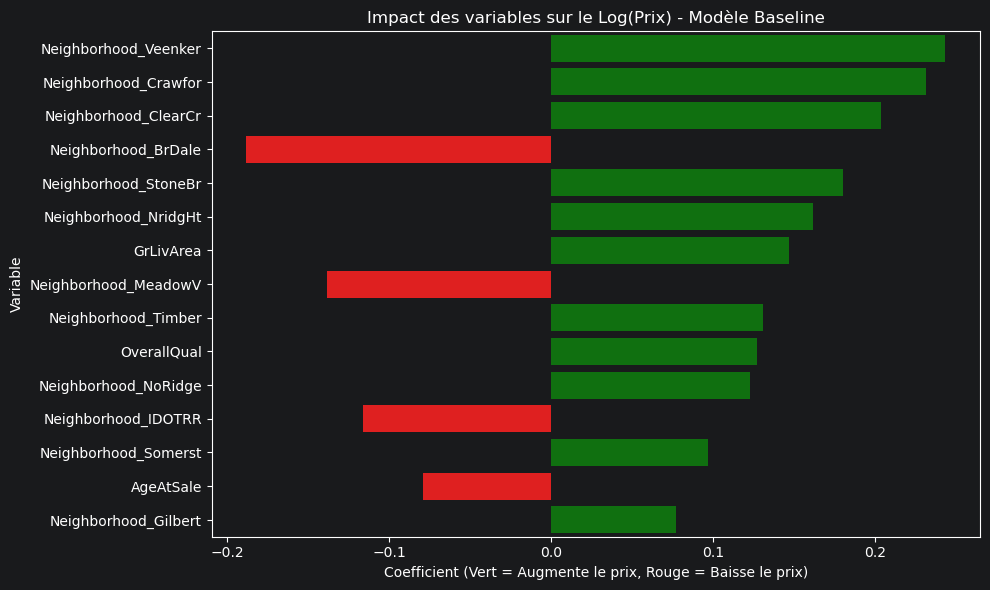


Génération du fichier de soumission Kaggle Baseline...
Fichier 'submission_baseline.csv' créé !


In [18]:
# 5. ENTRAÎNEMENT FINAL ET INTERPRÉTATION DES COEFFICIENTS

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("Entraînement du modèle Baseline sur 100% du Train Set...")
baseline_pipeline.fit(X_train, y_train_log)

# 1. Extraction des noms des colonnes après le ColumnTransformer
# Pour les colonnes numériques
num_cols = num_features + num_zero_features
# Pour les colonnes catégorielles (OneHotEncoded)
cat_encoder = baseline_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_cols = cat_encoder.get_feature_names_out(cat_features).tolist()

all_feature_names = num_cols + cat_cols

# 2. Extraction des coefficients de la Régression Linéaire
# On s'assure que les coefficients sont un tableau 1D (flatten)
coefficients = baseline_pipeline.named_steps['model'].coef_.flatten()

# 3. Création d'un tableau récapitulatif propre
coef_df = pd.DataFrame({
    'Variable': all_feature_names,
    'Coefficient_Log': coefficients
})

# Tri par l'impact absolu le plus fort
coef_df['Impact_Absolu'] = coef_df['Coefficient_Log'].abs()
coef_df = coef_df.sort_values(by='Impact_Absolu', ascending=False).drop(columns=['Impact_Absolu'])

print("\nTop 10 des variables les plus impactantes pour la Baseline :")
display(coef_df.head(10))

# 4. Visualisation simple des coefficients
plt.figure(figsize=(10, 6))
top_coefs = coef_df.head(15)

# --- CORRECTION DE L'ERREUR ICI (Ajout de .tolist()) ---
couleurs_barres = top_coefs['Coefficient_Log'].apply(lambda x: 'red' if x < 0 else 'green').tolist()

sns.barplot(
    data=top_coefs,
    x='Coefficient_Log',
    y='Variable',
    palette=couleurs_barres,
    hue='Variable', # Ajout recommandé par les nouvelles versions de Seaborn
    legend=False
)

plt.title('Impact des variables sur le Log(Prix) - Modèle Baseline')
plt.xlabel('Coefficient (Vert = Augmente le prix, Rouge = Baisse le prix)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# 5. SOUMISSION KAGGLE (Optionnelle pour la Baseline)
print("\nGénération du fichier de soumission Kaggle Baseline...")
log_predictions = baseline_pipeline.predict(X_test)
final_predictions = np.expm1(log_predictions)

submission = pd.DataFrame({
    'Id': sample_submission['Id'],
    'SalePrice': final_predictions
})

submission.to_csv('submission_baseline.csv', index=False)
print("Fichier 'submission_baseline.csv' créé !")

Génération des courbes d'apprentissage (patiente quelques secondes)...


/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  war

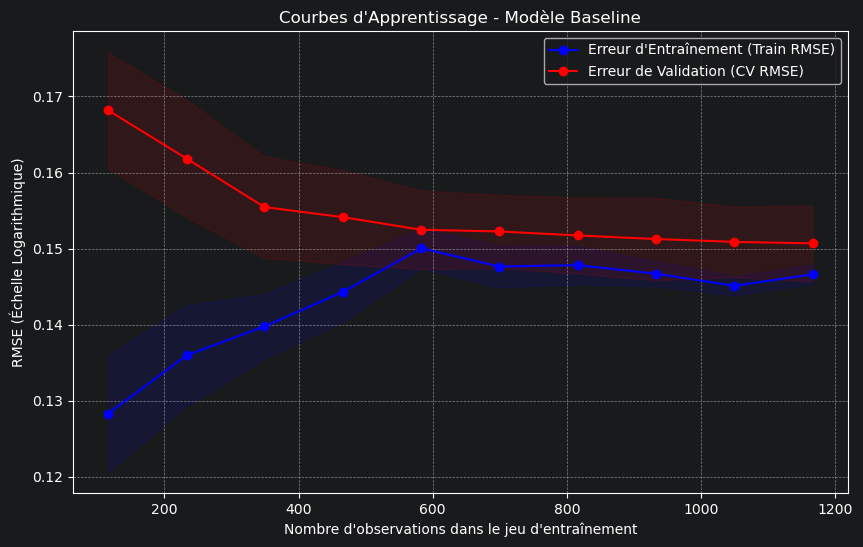


--- ANALYSE DU MODÈLE ---
Erreur Train finale : 0.1466
Erreur Val finale   : 0.1507
Écart (Gap)         : 0.0041
✅ Écart très faible : Excellente généralisation.


In [19]:
# 6. DIAGNOSTIC : COURBES D'APPRENTISSAGE (Learning Curves)

from sklearn.model_selection import learning_curve

def plot_learning_curves(pipeline, X, y, cv):
    print("Génération des courbes d'apprentissage (patiente quelques secondes)...")

    # On utilise le RMSE en log pour être cohérent avec l'évaluation Kaggle
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y, cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    # Conversion des scores négatifs en RMSE positif
    train_scores_mean = -train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    val_scores_mean = -val_scores.mean(axis=1)
    val_scores_std = val_scores.std(axis=1)

    # Visualisation
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Erreur d\'Entraînement (Train RMSE)')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')

    plt.plot(train_sizes, val_scores_mean, 'o-', color='red', label='Erreur de Validation (CV RMSE)')
    plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color='red')

    plt.xlabel('Nombre d\'observations dans le jeu d\'entraînement')
    plt.ylabel('RMSE (Échelle Logarithmique)')
    plt.title('Courbes d\'Apprentissage - Modèle Baseline')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # Analyse de l'écart final (Gap)
    final_train_error = train_scores_mean[-1]
    final_val_error = val_scores_mean[-1]
    final_gap = final_val_error - final_train_error

    print(f"\n--- ANALYSE DU MODÈLE ---")
    print(f"Erreur Train finale : {final_train_error:.4f}")
    print(f"Erreur Val finale   : {final_val_error:.4f}")
    print(f"Écart (Gap)         : {final_gap:.4f}")

    # Seuils adaptés à l'échelle logarithmique (RMSE Log)
    if final_gap > 0.05:
        print("⚠️ Écart important : Le modèle fait de l'overfitting (surapprentissage).")
    elif final_gap < 0.015:
        print("✅ Écart très faible : Excellente généralisation.")
        if final_train_error > 0.15:
             print("💡 Note : L'erreur globale est un peu haute. C'est de l'underfitting (typiquement attendu d'une Baseline).")
    else:
        print("📊 Écart modéré : Équilibre tout à fait acceptable.")

# Lancement sur notre Pipeline Baseline
plot_learning_curves(baseline_pipeline, X_train, y_train_log, cv=cv)

Analyse des résidus de la Baseline...
Moyenne des résidus : -0.0000 (Idéalement proche de 0)
Écart-type des résidus : 0.1470


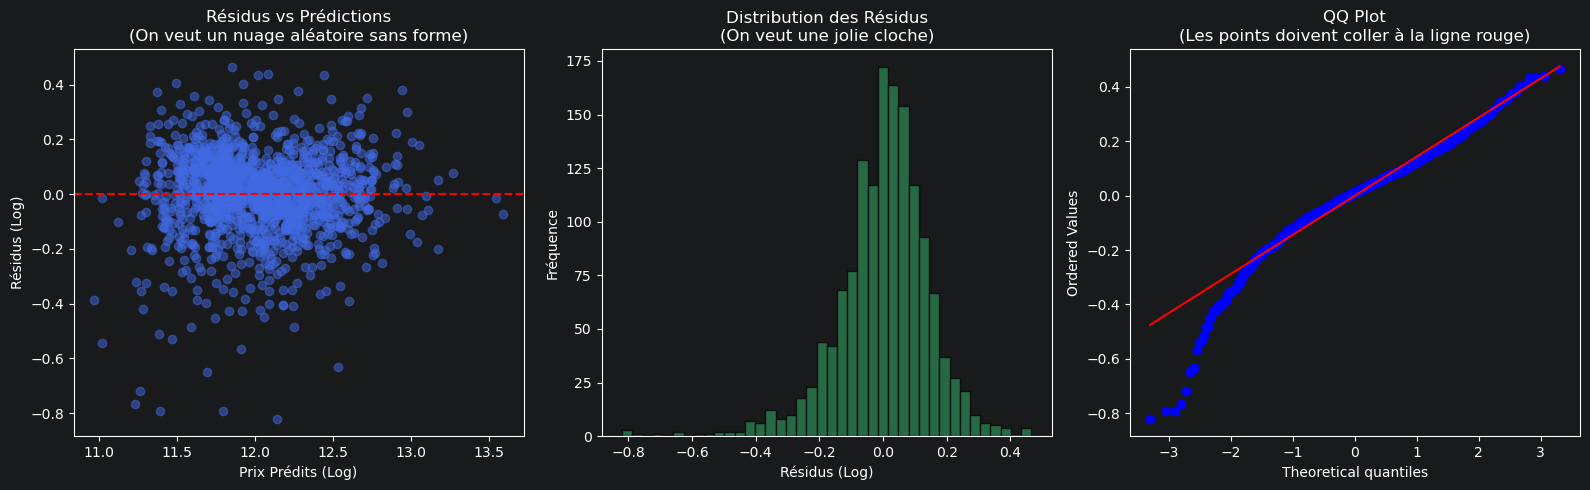

In [20]:
#7. DIAGNOSTIC : ANALYSE DES RÉSIDUS (Validation des hypothèses)

import scipy.stats as stats

print("Analyse des résidus de la Baseline...")

# On utilise les prédictions générées par notre modèle déjà entraîné à l'étape 5
pred_train_log = baseline_pipeline.predict(X_train)

# Calcul des résidus sur l'échelle Logarithmique (celle utilisée par le modèle)
residuals_log = y_train_log - pred_train_log

# Statistiques basiques
print(f"Moyenne des résidus : {np.mean(residuals_log):.4f} (Idéalement proche de 0)")
print(f"Écart-type des résidus : {np.std(residuals_log):.4f}")

# Visualisation complète
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Résidus vs Prédictions (Vérification de l'homoscédasticité)
axes[0].scatter(pred_train_log, residuals_log, alpha=0.5, color='royalblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Prix Prédits (Log)')
axes[0].set_ylabel('Résidus (Log)')
axes[0].set_title('Résidus vs Prédictions\n(On veut un nuage aléatoire sans forme)')

# 2. Histogramme (Vérification de la normalité des erreurs)
axes[1].hist(residuals_log, bins=40, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('Résidus (Log)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des Résidus\n(On veut une jolie cloche)')

# 3. QQ-Plot (Vérification stricte de la normalité)
stats.probplot(residuals_log, dist="norm", plot=axes[2])
axes[2].set_title('QQ Plot\n(Les points doivent coller à la ligne rouge)')

plt.tight_layout()
plt.show()

Génération des prédictions honnêtes (Out-Of-Fold) en cours...

--- PERFORMANCE MÉTIER ---
Erreur Moyenne Absolue (MAE) : 19,040 $
Marge d'erreur moyenne (MAPE): 11.3 %


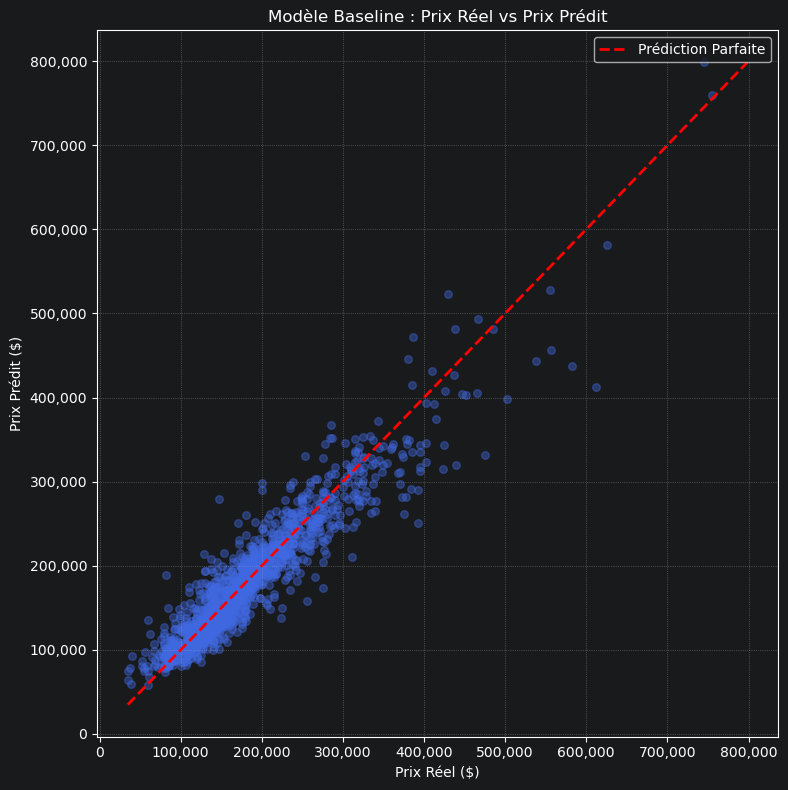

In [21]:
# 8. ÉVALUATION MÉTIER : PRIX RÉEL VS PRÉDIT (Out-Of-Fold)

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

print("Génération des prédictions honnêtes (Out-Of-Fold) en cours...")

# cross_val_predict remplace ta boucle "for" : il entraîne sur 4 folds et prédit sur le 5ème
oof_pred_log = cross_val_predict(baseline_pipeline, X_train, y_train_log, cv=cv, n_jobs=-1)

# Transformation inverse pour revenir en vrais dollars ($)
oof_pred_price = np.expm1(oof_pred_log)
y_train_price = y_train # y_train d'origine était déjà en dollars

# Calcul des métriques métier (en dollars et en pourcentage)
oof_mae = mean_absolute_error(y_train_price, oof_pred_price)
oof_mape = mean_absolute_percentage_error(y_train_price, oof_pred_price) * 100

print("\n--- PERFORMANCE MÉTIER ---")
print(f"Erreur Moyenne Absolue (MAE) : {oof_mae:,.0f} $")
print(f"Marge d'erreur moyenne (MAPE): {oof_mape:.1f} %")

# --- Visualisation ---
min_axis = min(y_train_price.min(), oof_pred_price.min())
max_axis = max(y_train_price.max(), oof_pred_price.max())

plt.figure(figsize=(8, 8))
plt.scatter(y_train_price, oof_pred_price, alpha=0.4, s=30, color="royalblue")
plt.plot([min_axis, max_axis], [min_axis, max_axis], color="red", linestyle="--", linewidth=2, label="Prédiction Parfaite")

# Formatage des axes pour afficher "k" (milliers) au lieu de l'écriture scientifique
formatter = plt.FuncFormatter(lambda x, p: format(int(x), ','))
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xlabel("Prix Réel ($)")
plt.ylabel("Prix Prédit ($)")
plt.title("Modèle Baseline : Prix Réel vs Prix Prédit")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()